# Model Training Basic





In [ ]:
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_1052c19cc1cd38d239291d4bdcf206e8"  # paste your full token here
print("Kaggle token set.")

Kaggle token set.


In [ ]:
!pip install -q kaggle
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset
!unzip -q new-plant-diseases-dataset.zip -d plant_data
print("Download and extraction complete.")


Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:24<00:00, 117MB/s] 

Download and extraction complete.


In [ ]:
import shutil, glob

base = "plant_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
train_src = os.path.join(base, "train")
valid_src = os.path.join(base, "valid")

tomato_dir = "tomato_data"
os.makedirs(os.path.join(tomato_dir, "train"), exist_ok=True)
os.makedirs(os.path.join(tomato_dir, "valid"), exist_ok=True)

tomato_classes = [d for d in os.listdir(train_src) if d.startswith("Tomato")]
print(f"Found {len(tomato_classes)} tomato classes:")
for c in tomato_classes:
    print(" -", c)

for c in tomato_classes:
    shutil.copytree(os.path.join(train_src, c), os.path.join(tomato_dir, "train", c), dirs_exist_ok=True)
    shutil.copytree(os.path.join(valid_src, c), os.path.join(tomato_dir, "valid", c), dirs_exist_ok=True)

print("Tomato-only dataset ready in ./tomato_data")

Found 10 tomato classes:
 - Tomato___Septoria_leaf_spot
 - Tomato___Target_Spot
 - Tomato___Bacterial_spot
 - Tomato___Early_blight
 - Tomato___Late_blight
 - Tomato___Leaf_Mold
 - Tomato___healthy
 - Tomato___Tomato_mosaic_virus
 - Tomato___Tomato_Yellow_Leaf_Curl_Virus
 - Tomato___Spider_mites Two-spotted_spider_mite
Tomato-only dataset ready in ./tomato_data


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
import json
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

valid_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "tomato_data/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

valid_generator = valid_datagen.flow_from_directory(
    "tomato_data/valid",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

num_classes = train_generator.num_classes
class_indices = train_generator.class_indices
print("Number of classes:", num_classes)
print(class_indices)

Found 18345 images belonging to 10 classes.
Found 4585 images belonging to 10 classes.
Number of classes: 10
{'Tomato___Bacterial_spot': 0, 'Tomato___Early_blight': 1, 'Tomato___Late_blight': 2, 'Tomato___Leaf_Mold': 3, 'Tomato___Septoria_leaf_spot': 4, 'Tomato___Spider_mites Two-spotted_spider_mite': 5, 'Tomato___Target_Spot': 6, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 7, 'Tomato___Tomato_mosaic_virus': 8, 'Tomato___healthy': 9}


In [ ]:
base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights="imagenet")
base_model.trainable = False  # freeze the pretrained base

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
predictions = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True),
    ModelCheckpoint("best_model.h5", monitor="val_accuracy", save_best_only=True)
]

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.6188 - loss: 1.1060

574/574 ━━━━━━━━━━━━━━━━━━━━ 268s 433ms/step - accuracy: 0.7253 - loss: 0.7986 - val_accuracy: 0.8218 - val_loss: 0.5097
Epoch 2/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.8214 - loss: 0.5236

574/574 ━━━━━━━━━━━━━━━━━━━━ 230s 400ms/step - accuracy: 0.8286 - loss: 0.5013 - val_accuracy: 0.8635 - val_loss: 0.3976
Epoch 3/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 225s 391ms/step - accuracy: 0.8528 - loss: 0.4197 - val_accuracy: 0.8438 - val_loss: 0.4375
Epoch 4/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 230s 401ms/step - accuracy: 0.8614 - loss: 0.4027 - val_accuracy: 0.8537 - val_loss: 0.4067
Epoch 5/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.8731 - loss: 0.3625

574/574 ━━━━━━━━━━━━━━━━━━━━ 226s 394ms/step - accuracy: 0.8734 - loss: 0.3610 - val_accuracy: 0.8901 - val_loss: 0.3257
Epoch 6/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 223s 388ms/step - accuracy: 0.8794 - loss: 0.3488 - val_accuracy: 0.8624 - val_loss: 0.3977
Epoch 7/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 220s 384ms/step - accuracy: 0.8826 - loss: 0.3312 - val_accuracy: 0.8831 - val_loss: 0.3276
Epoch 8/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.8887 - loss: 0.3210

574/574 ━━━━━━━━━━━━━━━━━━━━ 227s 395ms/step - accuracy: 0.8873 - loss: 0.3210 - val_accuracy: 0.8975 - val_loss: 0.3052
Epoch 9/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 230s 401ms/step - accuracy: 0.8903 - loss: 0.3136 - val_accuracy: 0.8907 - val_loss: 0.3244
Epoch 10/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 225s 392ms/step - accuracy: 0.8939 - loss: 0.3015 - val_accuracy: 0.8907 - val_loss: 0.3261
Epoch 11/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 223s 387ms/step - accuracy: 0.8956 - loss: 0.2947 - val_accuracy: 0.8964 - val_loss: 0.2969
Epoch 12/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.9062 - loss: 0.2685

574/574 ━━━━━━━━━━━━━━━━━━━━ 224s 391ms/step - accuracy: 0.9016 - loss: 0.2782 - val_accuracy: 0.8997 - val_loss: 0.3018
Epoch 13/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.9016 - loss: 0.2826

574/574 ━━━━━━━━━━━━━━━━━━━━ 225s 391ms/step - accuracy: 0.9020 - loss: 0.2823 - val_accuracy: 0.9005 - val_loss: 0.2869
Epoch 14/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 228s 397ms/step - accuracy: 0.9024 - loss: 0.2736 - val_accuracy: 0.8888 - val_loss: 0.3307
Epoch 15/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 227s 396ms/step - accuracy: 0.9070 - loss: 0.2636 - val_accuracy: 0.8955 - val_loss: 0.2902


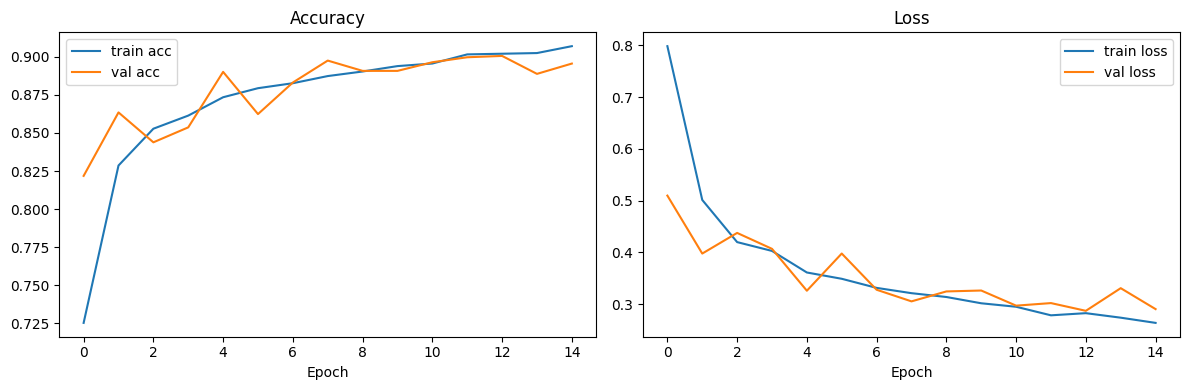

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="train acc")
axes[0].plot(history.history["val_accuracy"], label="val acc")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train loss")
axes[1].plot(history.history["val_loss"], label="val loss")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

144/144 ━━━━━━━━━━━━━━━━━━━━ 34s 158ms/step
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.87      0.99      0.93       425
                        Tomato___Early_blight       0.90      0.81      0.85       480
                         Tomato___Late_blight       0.96      0.89      0.92       463
                           Tomato___Leaf_Mold       0.87      0.95      0.91       470
                  Tomato___Septoria_leaf_spot       0.90      0.84      0.87       436
Tomato___Spider_mites Two-spotted_spider_mite       0.93      0.82      0.87       435
                         Tomato___Target_Spot       0.75      0.84      0.79       457
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.99      0.96      0.98       490
                 Tomato___Tomato_mosaic_virus       0.97      0.93      0.95       448
                             Tomato___healthy       0.89      0.97      0.93       48

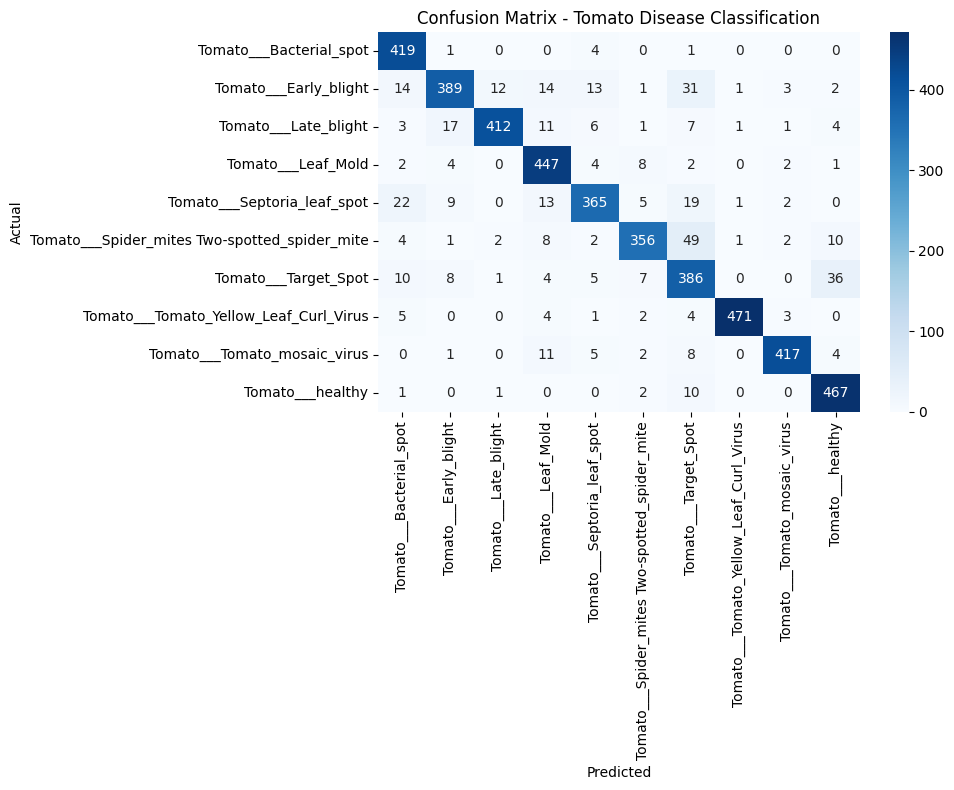

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

valid_generator.reset()
preds = model.predict(valid_generator, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = valid_generator.classes

class_names = list(class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("Confusion Matrix - Tomato Disease Classification")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_157']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


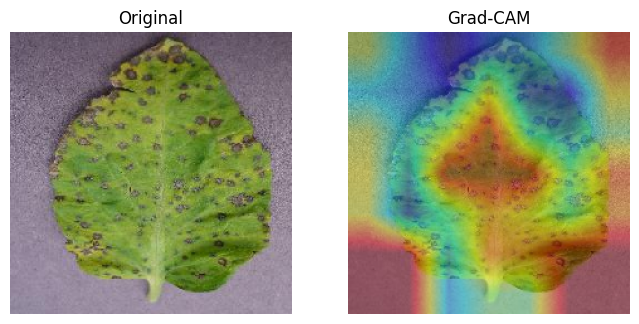

In [ ]:
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name="Conv_1", pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def display_gradcam(img_path, model, last_conv_layer_name="Conv_1"):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    original = np.uint8(img_array[0] * 255)
    superimposed = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(original)
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(superimposed)
    axes[1].set_title("Grad-CAM")
    axes[1].axis("off")
    plt.show()

# Test it on one validation image
sample_class = os.listdir("tomato_data/valid")[0]
sample_img_dir = os.path.join("tomato_data/valid", sample_class)
sample_img = os.path.join(sample_img_dir, os.listdir(sample_img_dir)[0])
display_gradcam(sample_img, model)

In [ ]:
model.save("tomato_model.h5")

idx_to_class = {v: k for k, v in class_indices.items()}
with open("class_indices.json", "w") as f:
    json.dump(idx_to_class, f)

print("Saved tomato_model.h5 and class_indices.json")

Saved tomato_model.h5 and class_indices.json


In [ ]:
from google.colab import files
files.download("tomato_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# idx_to_class = {v: k for k, v in class_indices.items()}
# with open("class_indices.json", "w") as f:
#     json.dump(idx_to_class, f)

# files.download("class_indices.json")

AttributeError: 'list' object has no attribute 'download'

# Model Training Fix

In [ ]:
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_1052c19cc1cd38d239291d4bdcf206e8"  # paste your full token here
print("Kaggle token set.")

Kaggle token set.


In [ ]:
!pip install -q kaggle
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset
!unzip -q new-plant-diseases-dataset.zip -d plant_data
print("Download and extraction complete.")


Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [02:16<00:00, 21.2MB/s]

Download and extraction complete.


In [ ]:
import shutil, glob

base = "plant_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
train_src = os.path.join(base, "train")
valid_src = os.path.join(base, "valid")

tomato_dir = "tomato_data"
os.makedirs(os.path.join(tomato_dir, "train"), exist_ok=True)
os.makedirs(os.path.join(tomato_dir, "valid"), exist_ok=True)

tomato_classes = [d for d in os.listdir(train_src) if d.startswith("Tomato")]
print(f"Found {len(tomato_classes)} tomato classes:")
for c in tomato_classes:
    print(" -", c)

for c in tomato_classes:
    shutil.copytree(os.path.join(train_src, c), os.path.join(tomato_dir, "train", c), dirs_exist_ok=True)
    shutil.copytree(os.path.join(valid_src, c), os.path.join(tomato_dir, "valid", c), dirs_exist_ok=True)

print("Tomato-only dataset ready in ./tomato_data")

Found 10 tomato classes:
 - Tomato___Septoria_leaf_spot
 - Tomato___Target_Spot
 - Tomato___Bacterial_spot
 - Tomato___Early_blight
 - Tomato___Late_blight
 - Tomato___Leaf_Mold
 - Tomato___healthy
 - Tomato___Tomato_mosaic_virus
 - Tomato___Tomato_Yellow_Leaf_Curl_Virus
 - Tomato___Spider_mites Two-spotted_spider_mite
Tomato-only dataset ready in ./tomato_data


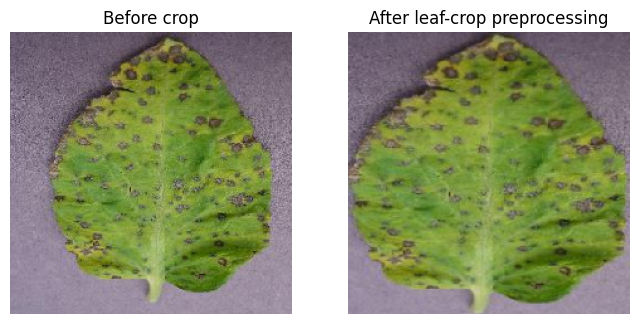

In [ ]:
import cv2

def crop_to_leaf_preprocess(img):
    """
    Roughly isolates the leaf from a plain background using HSV color thresholding.
    Input: a single image as a numpy array, shape (H, W, 3), values 0-255.
    Output: a numpy array of the SAME shape (IMG_SIZE, IMG_SIZE, 3), cropped to the
    leaf region if one was confidently detected, otherwise the original image.
    """
    img_uint8 = img.astype('uint8')
    hsv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2HSV)

    # Green / yellow / brown leaf tones (broad range to catch diseased + healthy leaves)
    lower = (10, 20, 20)
    upper = (100, 255, 255)
    mask = cv2.inRange(hsv, lower, upper)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest)
        # Sanity check: ignore tiny/noisy detections, fall back to original image
        if w > img_uint8.shape[1] * 0.2 and h > img_uint8.shape[0] * 0.2:
            cropped = img_uint8[y:y+h, x:x+w]
            cropped = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE))
            return cropped.astype('float32')

    return cv2.resize(img_uint8, (IMG_SIZE, IMG_SIZE)).astype('float32')


# Quick visual test on a sample image to confirm it's working sensibly
sample_class = os.listdir("tomato_data/valid")[0]
sample_dir = os.path.join("tomato_data/valid", sample_class)
sample_path = os.path.join(sample_dir, os.listdir(sample_dir)[0])

test_img = tf.keras.preprocessing.image.load_img(sample_path, target_size=(IMG_SIZE, IMG_SIZE))
test_img_arr = tf.keras.preprocessing.image.img_to_array(test_img)
cropped_result = crop_to_leaf_preprocess(test_img_arr)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(test_img_arr.astype('uint8'))
axes[0].set_title("Before crop")
axes[0].axis("off")
axes[1].imshow(cropped_result.astype('uint8'))
axes[1].set_title("After leaf-crop preprocessing")
axes[1].axis("off")
plt.show()


In [ ]:
!kaggle datasets download -d nirmalsankalana/plantdoc-dataset
!unzip -q plantdoc-dataset.zip -d plantdoc_data
print("PlantDoc downloaded and extracted.")

# See what folders we actually got, since naming can vary between re-uploads
for root, dirs, files in os.walk("plantdoc_data"):
    for d in dirs:
        print(os.path.join(root, d))

Dataset URL: https://www.kaggle.com/datasets/nirmalsankalana/plantdoc-dataset
License(s): CC0-1.0
100% 896M/896M [00:43<00:00, 21.6MB/s]

PlantDoc downloaded and extracted.
plantdoc_data/train
plantdoc_data/test
plantdoc_data/train/Apple_Scab_Leaf
plantdoc_data/train/Corn_rust_leaf
plantdoc_data/train/Tomato_two_spotted_spider_mites_leaf
plantdoc_data/train/Tomato_leaf_bacterial_spot
plantdoc_data/train/Peach_leaf
plantdoc_data/train/grape_leaf_black_rot
plantdoc_data/train/Apple_rust_leaf
plantdoc_data/train/Tomato_mold_leaf
plantdoc_data/train/Squash_Powdery_mildew_leaf
plantdoc_data/train/Soyabean_leaf
plantdoc_data/train/Tomato_leaf_mosaic_virus
plantdoc_data/train/Potato_leaf_late_blight
plantdoc_data/train/Tomato_leaf
plantdoc_data/train/Corn_leaf_blight
plantdoc_data/train/Apple_leaf
plantdoc_data/train/Corn_Gray_leaf_spot
plantdoc_data/train/Blueberry_leaf
plantdoc_data/train/Bell_pepper_leaf
plantdoc_data/train/Tomato_leaf_late_blight
plantdoc_data/train/Cherry_leaf
plantdoc_d

In [ ]:
import random
random.seed(42)

# Map PlantDoc folder names (lowercased, keyword-matched) to our class names.
# NOTE: run the cell above first and check the printed folder names — if PlantDoc's
# folder names differ from what's matched below, adjust the keyword checks accordingly.

def map_plantdoc_folder(folder_name):
    name = folder_name.lower()
    if "tomato" not in name:
        return None
    if "bacterial" in name:
        return "Tomato___Bacterial_spot"
    if "early" in name:
        return "Tomato___Early_blight"
    if "late" in name:
        return "Tomato___Late_blight"
    if "mold" in name:
        return "Tomato___Leaf_Mold"
    if "septoria" in name:
        return "Tomato___Septoria_leaf_spot"
    if "mosaic" in name:
        return "Tomato___Tomato_mosaic_virus"
    if "yellow" in name:
        return "Tomato___Tomato_Yellow_Leaf_Curl_Virus"
    if name.strip() == "tomato leaf":
        return "Tomato___healthy"
    return None  # unmatched — will be printed below for manual review


# Find the actual PlantDoc root folder (structure can vary by upload)
plantdoc_root = None
for root, dirs, files in os.walk("plantdoc_data"):
    if any("tomato" in d.lower() for d in dirs):
        plantdoc_root = root
        break

if plantdoc_root is None:
    print("Could not auto-detect the PlantDoc folder structure — check the printed "
          "folder list above and set plantdoc_root manually.")
else:
    print("Using PlantDoc root:", plantdoc_root)

    combined_train_dir = "combined_train"
    realworld_test_dir = "realworld_test"
    os.makedirs(combined_train_dir, exist_ok=True)
    os.makedirs(realworld_test_dir, exist_ok=True)

    # Start combined_train as a copy of our existing tomato_data/train
    for c in os.listdir("tomato_data/train"):
        shutil.copytree(os.path.join("tomato_data/train", c),
                         os.path.join(combined_train_dir, c), dirs_exist_ok=True)

    unmatched = set()
    matched_count = 0

    for folder in os.listdir(plantdoc_root):
        mapped_class = map_plantdoc_folder(folder)
        folder_path = os.path.join(plantdoc_root, folder)
        if not os.path.isdir(folder_path):
            continue
        if mapped_class is None:
            if "tomato" in folder.lower():
                unmatched.add(folder)
            continue

        images = [f for f in os.listdir(folder_path)
                  if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        random.shuffle(images)
        split_idx = int(len(images) * 0.7)
        train_imgs, test_imgs = images[:split_idx], images[split_idx:]

        os.makedirs(os.path.join(combined_train_dir, mapped_class), exist_ok=True)
        os.makedirs(os.path.join(realworld_test_dir, mapped_class), exist_ok=True)

        for img_name in train_imgs:
            shutil.copy(os.path.join(folder_path, img_name),
                        os.path.join(combined_train_dir, mapped_class, f"pd_{img_name}"))
        for img_name in test_imgs:
            shutil.copy(os.path.join(folder_path, img_name),
                        os.path.join(realworld_test_dir, mapped_class, f"pd_{img_name}"))

        matched_count += len(images)

    print(f"Matched and split {matched_count} PlantDoc tomato images.")
    if unmatched:
        print("Unmatched tomato-related folders (review these manually):", unmatched)


Using PlantDoc root: plantdoc_data/train
Matched and split 778 PlantDoc tomato images.
Unmatched tomato-related folders (review these manually): {'Tomato_two_spotted_spider_mites_leaf', 'Tomato_leaf'}


In [ ]:
train_datagen_v2 = ImageDataGenerator(
    preprocessing_function=crop_to_leaf_preprocess,
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.25,
    brightness_range=[0.7, 1.3],
    shear_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="nearest"
)

valid_datagen_v2 = ImageDataGenerator(
    preprocessing_function=crop_to_leaf_preprocess,
    rescale=1./255
)

train_generator_v2 = train_datagen_v2.flow_from_directory(
    "combined_train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

# Keep validating against the ORIGINAL PlantVillage valid set for a like-for-like
# comparison against Part 1's numbers
valid_generator_v2 = valid_datagen_v2.flow_from_directory(
    "tomato_data/valid",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

MODEL_CLASSES = list(train_generator_v2.class_indices.keys())

realworld_test_generator = valid_datagen_v2.flow_from_directory(
    "realworld_test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
    classes=MODEL_CLASSES
)

print(realworld_test_generator.class_indices)

print("Combined train classes:", train_generator_v2.class_indices)


Found 18886 images belonging to 10 classes.
Found 4585 images belonging to 10 classes.
Found 237 images belonging to 10 classes.
{'Tomato___Bacterial_spot': 0, 'Tomato___Early_blight': 1, 'Tomato___Late_blight': 2, 'Tomato___Leaf_Mold': 3, 'Tomato___Septoria_leaf_spot': 4, 'Tomato___Spider_mites Two-spotted_spider_mite': 5, 'Tomato___Target_Spot': 6, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 7, 'Tomato___Tomato_mosaic_virus': 8, 'Tomato___healthy': 9}
Combined train classes: {'Tomato___Bacterial_spot': 0, 'Tomato___Early_blight': 1, 'Tomato___Late_blight': 2, 'Tomato___Leaf_Mold': 3, 'Tomato___Septoria_leaf_spot': 4, 'Tomato___Spider_mites Two-spotted_spider_mite': 5, 'Tomato___Target_Spot': 6, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 7, 'Tomato___Tomato_mosaic_virus': 8, 'Tomato___healthy': 9}


In [ ]:
print("Unique labels in y_true:", np.unique(realworld_test_generator.classes))
print("Number of unique labels:", len(np.unique(realworld_test_generator.classes)))
print("Total classes:", len(realworld_test_generator.class_indices))

Unique labels in y_true: [0 1 2 3 4 7 8]
Number of unique labels: 7
Total classes: 10


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)
print("Recompiled with label smoothing.")


Recompiled with label smoothing.


In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

fine_tune_callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    ModelCheckpoint("tomato_model.h5", monitor="val_accuracy", save_best_only=True)
]

history_v2 = model.fit(
    train_generator_v2,
    validation_data=valid_generator_v2,
    epochs=20,
    callbacks=fine_tune_callbacks
)


Epoch 1/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.3996 - loss: 1.8676

591/591 ━━━━━━━━━━━━━━━━━━━━ 335s 540ms/step - accuracy: 0.4896 - loss: 1.6825 - val_accuracy: 0.6113 - val_loss: 1.4434
Epoch 2/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.6580 - loss: 1.3331

591/591 ━━━━━━━━━━━━━━━━━━━━ 292s 494ms/step - accuracy: 0.6837 - loss: 1.2706 - val_accuracy: 0.7529 - val_loss: 1.1332
Epoch 3/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.7349 - loss: 1.1583

591/591 ━━━━━━━━━━━━━━━━━━━━ 294s 497ms/step - accuracy: 0.7454 - loss: 1.1308 - val_accuracy: 0.8137 - val_loss: 0.9830
Epoch 4/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.7788 - loss: 1.0662

591/591 ━━━━━━━━━━━━━━━━━━━━ 294s 497ms/step - accuracy: 0.7859 - loss: 1.0476 - val_accuracy: 0.8556 - val_loss: 0.8945
Epoch 5/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.8028 - loss: 1.0086

...

591/591 ━━━━━━━━━━━━━━━━━━━━ 291s 493ms/step - accuracy: 0.9082 - loss: 0.7851 - val_accuracy: 0.9426 - val_loss: 0.6982
Epoch 16/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.9112 - loss: 0.7811

591/591 ━━━━━━━━━━━━━━━━━━━━ 288s 488ms/step - accuracy: 0.9086 - loss: 0.7825 - val_accuracy: 0.9431 - val_loss: 0.6939
Epoch 17/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.9103 - loss: 0.7742

591/591 ━━━━━━━━━━━━━━━━━━━━ 288s 487ms/step - accuracy: 0.9131 - loss: 0.7727 - val_accuracy: 0.9457 - val_loss: 0.6899
Epoch 18/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.9176 - loss: 0.7652

591/591 ━━━━━━━━━━━━━━━━━━━━ 298s 505ms/step - accuracy: 0.9187 - loss: 0.7644 - val_accuracy: 0.9492 - val_loss: 0.6815
Epoch 19/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.9222 - loss: 0.7539

591/591 ━━━━━━━━━━━━━━━━━━━━ 309s 484ms/step - accuracy: 0.9220 - loss: 0.7540 - val_accuracy: 0.9577 - val_loss: 0.6684
Epoch 20/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 293s 497ms/step - accuracy: 0.9235 - loss: 0.7502 - val_accuracy: 0.9557 - val_loss: 0.6720


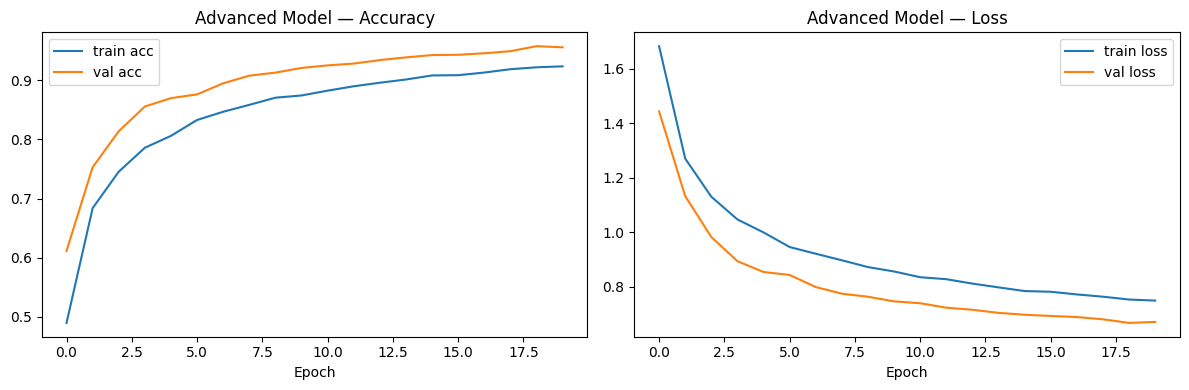

In [ ]:
# Plot the advanced training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_v2.history["accuracy"], label="train acc")
axes[0].plot(history_v2.history["val_accuracy"], label="val acc")
axes[0].set_title("Advanced Model — Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_v2.history["loss"], label="train loss")
axes[1].plot(history_v2.history["val_loss"], label="val loss")
axes[1].set_title("Advanced Model — Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
print("Validation classes:")
print(valid_generator_v2.class_indices)

print("\nPlantDoc classes:")
print(realworld_test_generator.class_indices)

print("\nValidation class count:", len(valid_generator_v2.class_indices))
print("PlantDoc class count:", len(realworld_test_generator.class_indices))

Validation classes:
{'Tomato___Bacterial_spot': 0, 'Tomato___Early_blight': 1, 'Tomato___Late_blight': 2, 'Tomato___Leaf_Mold': 3, 'Tomato___Septoria_leaf_spot': 4, 'Tomato___Spider_mites Two-spotted_spider_mite': 5, 'Tomato___Target_Spot': 6, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 7, 'Tomato___Tomato_mosaic_virus': 8, 'Tomato___healthy': 9}

PlantDoc classes:
{'Tomato___Bacterial_spot': 0, 'Tomato___Early_blight': 1, 'Tomato___Late_blight': 2, 'Tomato___Leaf_Mold': 3, 'Tomato___Septoria_leaf_spot': 4, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 5, 'Tomato___Tomato_mosaic_virus': 6}

Validation class count: 10
PlantDoc class count: 7


144/144 ━━━━━━━━━━━━━━━━━━━━ 16s 107ms/step

===== PlantVillage Validation Set (lab images) =====
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.93      0.99      0.96       425
                        Tomato___Early_blight       0.96      0.91      0.94       480
                         Tomato___Late_blight       0.97      0.96      0.96       463
                           Tomato___Leaf_Mold       0.97      0.97      0.97       470
                  Tomato___Septoria_leaf_spot       0.95      0.92      0.94       436
Tomato___Spider_mites Two-spotted_spider_mite       0.96      0.94      0.95       435
                         Tomato___Target_Spot       0.89      0.95      0.92       457
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       1.00      0.99      0.99       490
                 Tomato___Tomato_mosaic_virus       1.00      0.97      0.98       448
                             To

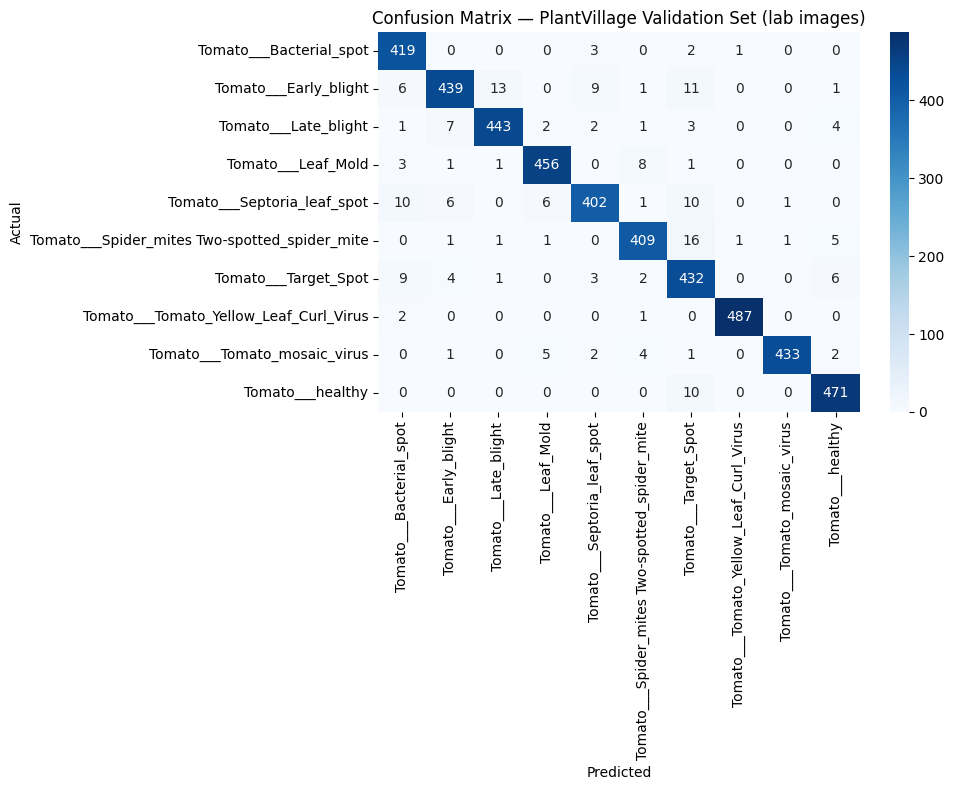

8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 880ms/step

===== Real-World Held-Out Test Set (PlantDoc) =====
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.29      0.19      0.23        31
                        Tomato___Early_blight       0.47      0.58      0.52        24
                         Tomato___Late_blight       0.59      0.71      0.65        31
                           Tomato___Leaf_Mold       0.61      0.42      0.50        26
                  Tomato___Septoria_leaf_spot       0.50      0.57      0.53        44
Tomato___Spider_mites Two-spotted_spider_mite       0.00      0.00      0.00         0
                         Tomato___Target_Spot       0.00      0.00      0.00         0
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.73      0.84      0.78        67
                 Tomato___Tomato_mosaic_virus       1.00      0.14      0.25        14
                             Tomato__

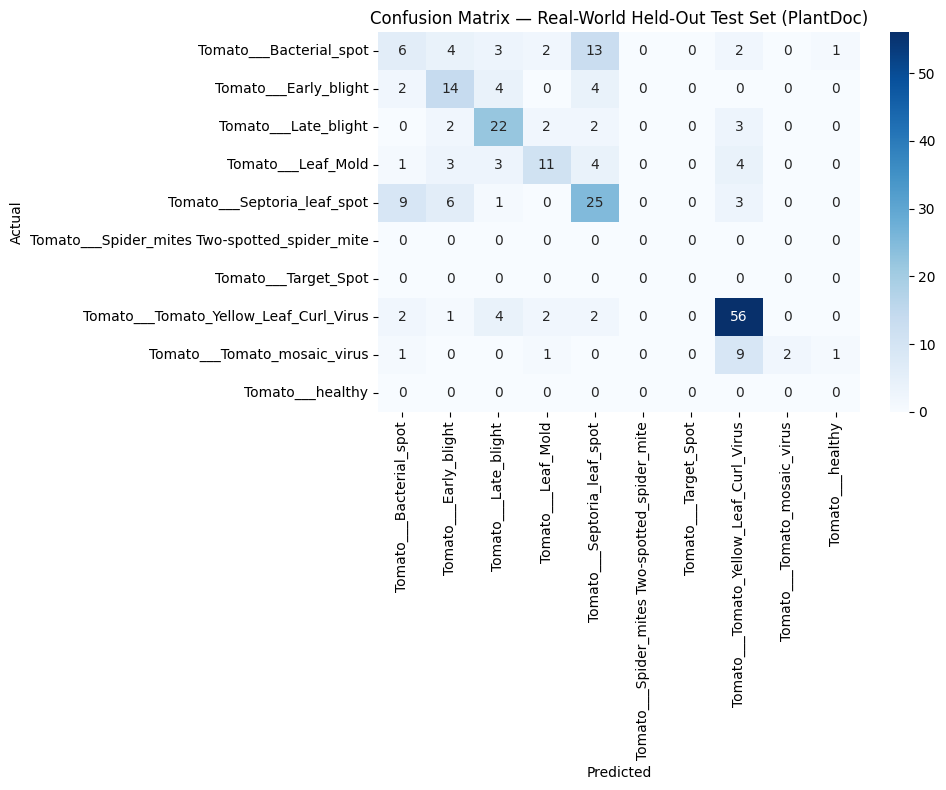

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def evaluate_generator(generator, name):
    generator.reset()

    preds = model.predict(generator, verbose=1)
    y_pred = np.argmax(preds, axis=1)
    y_true = generator.classes

    class_names_local = list(generator.class_indices.keys())
    labels = list(range(len(class_names_local)))   # Force all 10 classes

    print(f"\n===== {name} =====")

    print(classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=class_names_local,
        zero_division=0
    ))

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    plt.figure(figsize=(10,8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names_local,
        yticklabels=class_names_local
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {name}")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


evaluate_generator(valid_generator_v2, "PlantVillage Validation Set (lab images)")
evaluate_generator(realworld_test_generator, "Real-World Held-Out Test Set (PlantDoc)")

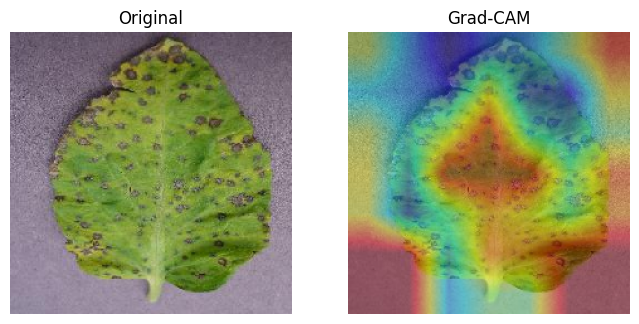

In [ ]:
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name="Conv_1", pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def display_gradcam(img_path, model, last_conv_layer_name="Conv_1"):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    original = np.uint8(img_array[0] * 255)
    superimposed = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(original)
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(superimposed)
    axes[1].set_title("Grad-CAM")
    axes[1].axis("off")
    plt.show()

# Test it on one validation image
sample_class = os.listdir("tomato_data/valid")[0]
sample_img_dir = os.path.join("tomato_data/valid", sample_class)
sample_img = os.path.join(sample_img_dir, os.listdir(sample_img_dir)[0])
display_gradcam(sample_img, model)

In [ ]:
model.save("tomato_model_advanced.h5")
print("Saved tomato_model_advanced.h5")

from google.colab import files
files.download("tomato_model_advanced.h5")


Saved tomato_model_advanced.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
idx_to_class = {v: k for k, v in class_indices.items()}
with open("class_indices.json", "w") as f:
    json.dump(idx_to_class, f)

files.download("class_indices.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>